In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [2]:
df = pd.read_csv("mexico_housing.csv")
df.head()


,price,surface_total_m2,city,lat,lon
0,151958,303,Puebla,22.982831,-93.134036
1,176867,50,Monterrey,28.630167,-106.090898
2,161932,304,Puebla,17.335355,-99.148377
3,395838,289,Mexico City,30.523681,-106.918865
4,289178,362,Puebla,24.856847,-86.828431


In [3]:
# Features and target
X = df[["surface_total_m2", "city", "lat", "lon"]]
y = df["price"]

# One-hot encode categorical feature (city)
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(), ["city"])],
    remainder='passthrough'
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  ['city'])])),
                ('regressor', LinearRegression())])

In [5]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


RMSE: 135890.77792734103


In [6]:
new_house = pd.DataFrame({
    "surface_total_m2": [120],
    "city": ["Guadalajara"],
    "lat": [20.67],
    "lon": [-103.35]
})

predicted_price = model.predict(new_house)
predicted_price


array([265092.94401123])

In [7]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
# Random Forest Regressor
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),   # same as before
    ("regressor", RandomForestRegressor(
        n_estimators=100,  # number of trees
        random_state=42
    ))
])


In [9]:
rf_model.fit(X_train, y_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  ['city'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [10]:
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)


Random Forest RMSE: 140803.04711556464


In [11]:
new_house = pd.DataFrame({
    "surface_total_m2": [120],
    "city": ["Guadalajara"],
    "lat": [20.67],
    "lon": [-103.35]
})

predicted_price_rf = rf_model.predict(new_house)
predicted_price_rf


array([281989.97])

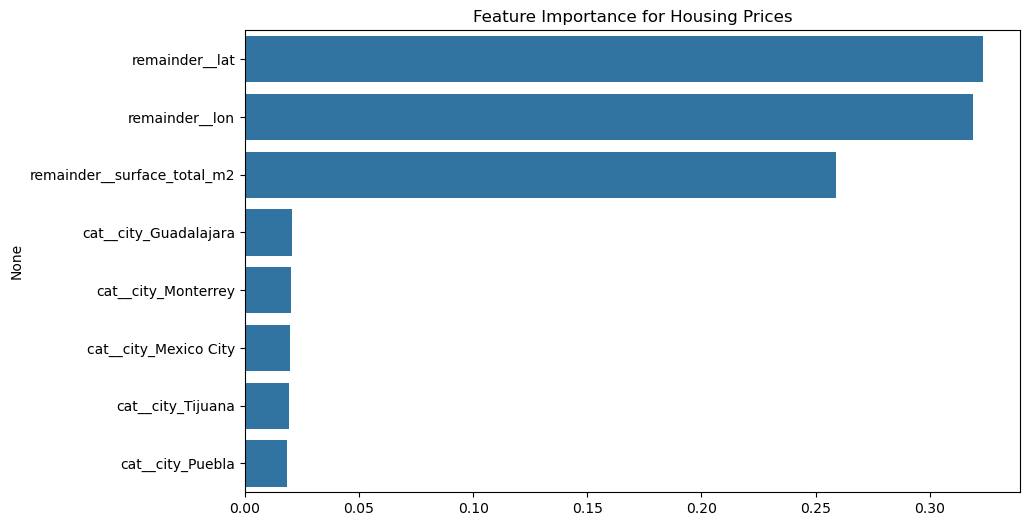

In [12]:
# Extract trained Random Forest from pipeline
rf = rf_model.named_steps['regressor']

# Get feature names (after one-hot encoding)
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance for Housing Prices")
plt.show()


In [13]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Show plots in notebook
%matplotlib inline


In [14]:
# Load the CSV
df = pd.read_csv("mexico_housing.csv")
df.head()
df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             21000 non-null  int64  
 1   surface_total_m2  21000 non-null  int64  
 2   city              21000 non-null  object 
 3   lat               21000 non-null  float64
 4   lon               21000 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 820.4+ KB


price               0
surface_total_m2    0
city                0
lat                 0
lon                 0
dtype: int64

In [15]:
# Remove extreme outliers (top 1%)
df = df[df["price"] <= df["price"].quantile(0.99)]
df = df[df["surface_total_m2"] <= df["surface_total_m2"].quantile(0.99)]
df.shape


(20617, 5)

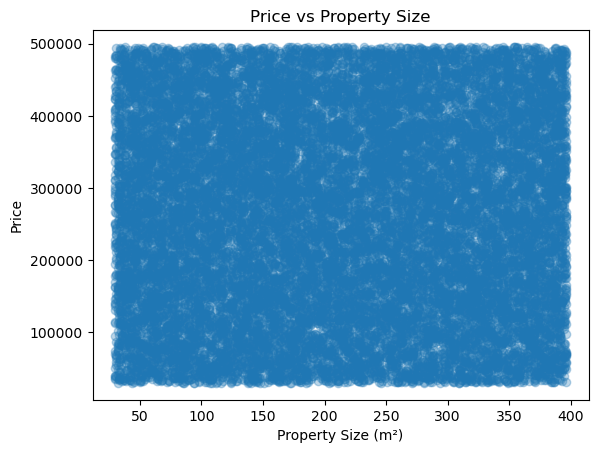

Correlation between price and size: 0.005506270405311331


In [16]:
plt.figure()
plt.scatter(df["surface_total_m2"], df["price"], alpha=0.3)
plt.xlabel("Property Size (m²)")
plt.ylabel("Price")
plt.title("Price vs Property Size")
plt.show()

corr_size = df["price"].corr(df["surface_total_m2"])
print("Correlation between price and size:", corr_size)


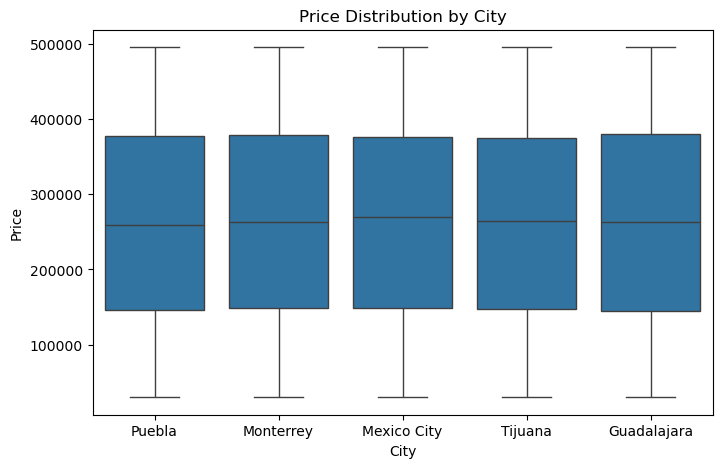

In [17]:
top_cities = df["city"].value_counts().head(5).index
city_df = df[df["city"].isin(top_cities)]

plt.figure(figsize=(8,5))
sns.boxplot(x="city", y="price", data=city_df)
plt.title("Price Distribution by City")
plt.xlabel("City")
plt.ylabel("Price")
plt.show()


In [18]:
df[["price", "lat", "lon"]].corr()


,price,lat,lon
price,1.000000,0.004073,0.012060
lat,0.004073,1.000000,-0.015218
lon,0.012060,-0.015218,1.000000


In [19]:
# Features and target
X = df[["surface_total_m2", "city", "lat", "lon"]]
y = df["price"]

# One-hot encode city
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(), ["city"])],
    remainder='passthrough'
)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", rmse_lr)


Linear Regression RMSE: 132210.03866234887


In [21]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)


Random Forest RMSE: 137692.8259334709


In [22]:
new_house = pd.DataFrame({
    "surface_total_m2": [120],
    "city": ["Guadalajara"],
    "lat": [20.67],
    "lon": [-103.35]
})

predicted_price_rf = rf_model.predict(new_house)
print("Predicted Price (Random Forest):", predicted_price_rf[0])


Predicted Price (Random Forest): 267117.63


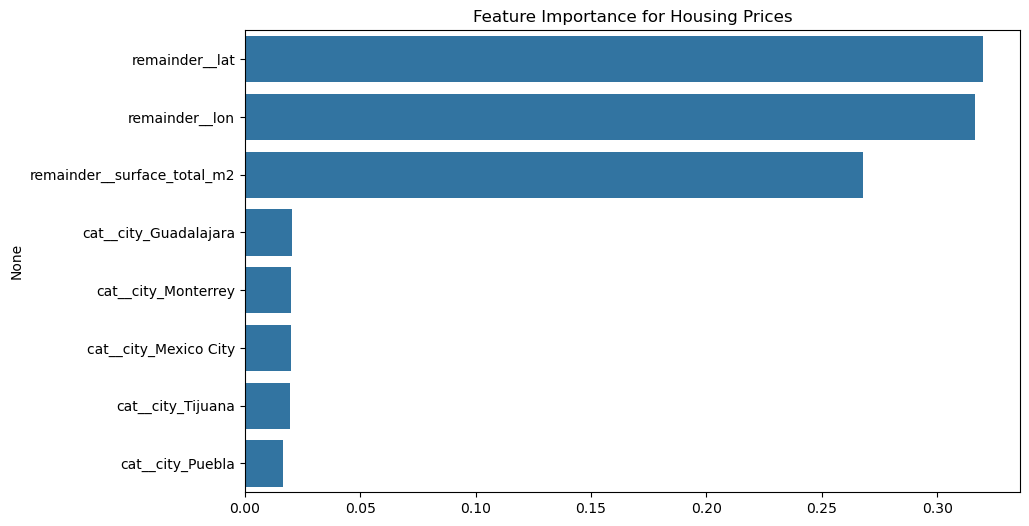

In [23]:
# Extract trained Random Forest
rf = rf_model.named_steps['regressor']

# Get feature names
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance for Housing Prices")
plt.show()
